In [12]:
!pip install neuralforecast
!pip install graphviz

   ---------------------------------------- 0.0/47.3 kB ? eta -:--:--
   ----------------- ---------------------- 20.5/47.3 kB 640.0 kB/s eta 0:00:01
   ---------------------------------- ----- 41.0/47.3 kB 653.6 kB/s eta 0:00:01
   ---------------------------------------- 47.3/47.3 kB 588.3 kB/s eta 0:00:00


In [ ]:
# -*- coding: utf-8 -*-
"""
ПОЛНЫЙ АНАЛИЗ И ПРОГНОЗИРОВАНИЕ ЭЛЕКТРОПОТРЕБЛЕНИЯ
с использованием модели N-BEATSx

Данный ноутбук включает:
1. Разведочный анализ данных (EDA)
2. Предобработку и создание признаков
3. Построение корреляционных матриц и графиков
4. Обучение модели N-BEATSx на 10 годах (2013-2022)
5. Оценку на первых 5 месяцах 2025 года
6. Визуализацию результатов и расчёт метрик (MAE, MAPE)
7. (Опционально) расчёт финансовых потерь на балансирующем рынке
"""

# =============================================================================
# 1. ИМПОРТ БИБЛИОТЕК
# =============================================================================
import os
os.makedirs('pictures', exist_ok=True)
import re
import copy
import locale
import requests
import warnings
import calendar
from bs4 import BeautifulSoup
from tqdm.notebook import trange

import notebook
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from platform import python_version
import graphviz
from datetime import time, datetime, timedelta
import sklearn
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.model_selection import GridSearchCV

# Библиотека для N-BEATSx
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import MAE as MAE_torch

print(f"python: v {python_version()}")
print(f"Jupyter Notebook: v {notebook.__version__}")
print(f"numpy: v {np.__version__}")
print(f"pandas: v {pd.__version__}")
print(f"seaborn: v {sns.__version__}")
print(f"graphviz: v {graphviz.__version__}")
print(f"matplotlib: v {matplotlib.__version__}")
print(f"sklearn: v {sklearn.__version__}")

plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = 12

warnings.filterwarnings('ignore')

In [ ]:
# =============================================================================
# 2. ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ
# =============================================================================
df = pd.read_excel('DataBase.xlsx')
print("Исходные данные:")
df.info()
print("\nПервые 5 строк:")
print(df.head())


In [ ]:
# =============================================================================
# 3. ФУНКЦИИ ДЛЯ ПРЕДОБРАБОТКИ (из кода преподавателя)
# =============================================================================
def get_type_day(df_row):
    """
    Классификация дня по типу: рабочий, предпраздничный, выходной, праздничный.
    ВНИМАНИЕ: списки дат должны быть полными (вставьте свои данные)
    """
    holidays = [
        datetime(2013, 1, 1).date(), datetime(2013, 1, 2).date(),
        # ... ВСТАВЬТЕ ПОЛНЫЙ СПИСОК ...
        datetime(2025, 11, 6).date()
    ]
    weekend = [
        datetime(2013, 5, 2).date(), datetime(2013, 5, 3).date(),
        # ... ВСТАВЬТЕ ПОЛНЫЙ СПИСОК ...
        datetime(2025, 12, 31).date()
    ]
    pre_holidays = [
        datetime(2013, 2, 22).date(), datetime(2013, 3, 7).date(),
        # ... ВСТАВЬТЕ ПОЛНЫЙ СПИСОК ...
        datetime(2025, 11, 5).date()
    ]
    workdays = [datetime(2024, 4, 27).date(), datetime(2024, 12, 28).date()]

    date_val = df_row['Date'].date()
    if date_val in workdays:
        return 0
    elif date_val in pre_holidays:
        return 1
    elif date_val in weekend:
        return 3
    elif date_val in holidays:
        return 2
    elif df_row['Weekday'] in [5, 6]:
        return 3
    else:
        return 0

def prepareData(df, lag_start=1, lag_end=7):
    """
    Добавляет тип дня и лаги целевой переменной.
    Возвращает DataFrame с колонкой 'TypeDay' и лагами.
    """
    df = df.copy()
    df['TypeDay'] = df.apply(get_type_day, axis=1)
    df = df.set_index('Date')
    for i in range(lag_start, lag_end + 1):
        df[f"lag-{i}"] = df['Volume'].shift(freq=f"{i}D")
    df = df.dropna(subset=[f"lag-{i}" for i in range(lag_start, lag_end + 1)])
    df.reset_index(inplace=True)
    return df


In [ ]:
# =============================================================================
# 4. ПРЕДОБРАБОТКА ДАННЫХ
# =============================================================================
df_general = prepareData(df)
df_general = df_general.drop(columns=['PredCons', 'PredGen'], errors='ignore')
print(f"\nРазмер после предобработки: {df_general.shape}")
print(f"Колонки: {df_general.columns.tolist()}")

In [ ]:
# =============================================================================
# 5. РАЗВЕДОЧНЫЙ АНАЛИЗ (все графики из кода преподавателя)
# =============================================================================
# 5.1. График полной структуры потребления (по месяцам)
def graf_full_consumption(df, fontsize=20):
    df_group = df.groupby(['Year', 'Month'])[['Volume']].mean().reset_index()
    fig, ax1 = plt.subplots(figsize=(16,7))
    ax2 = ax1.twinx()
    ax1.plot(df_group.Volume, label='Volume')
    ax2.plot(df_group.Year, color='red', label='Year')
    ax1.set_xlim(0, df_group.shape[0])
    ax1.set_ylabel('Volume, MWh', fontsize=fontsize+2, color='#1f77b4')
    ax1.set_xlabel('Number of Months', fontsize=fontsize+2)
    ax2.set_ylabel('Year', fontsize=fontsize+2, color='r')
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1.00))
    plt.title(f'Сonsumption structure for 12.5 years ({df.iloc[0].Date.date()} – {df.iloc[-1].Date.date()})',
              fontsize=fontsize+2)
    plt.tight_layout()
    plt.savefig('pictures/graf_full_consumption.png', dpi=300, transparent=True)
    plt.show()

graf_full_consumption(df)


In [ ]:
# 5.2. График потребления за конкретный год (2024)
def graf_year_consumption(df, year, fontsize=20):
    df_year = df[df.Year == year].reset_index(drop=True)
    df_group = df_year.groupby(['Month', 'Day'])[['Volume']].mean().reset_index()
    fig, ax1 = plt.subplots(figsize=(16,6))
    ax2 = ax1.twinx()
    ax1.plot(df_group.Volume, label='Volume')
    ax2.plot(df_group.Month, color='r', label='Month')
    ax1.set_xlim(0, df_group.shape[0])
    ax1.set_ylabel('Volume, MWh', fontsize=fontsize+2, color='#1f77b4')
    ax1.set_xlabel('Number of Days', fontsize=fontsize+2)
    ax2.yaxis.set_major_locator(ticker.FixedLocator(range(1,13)))
    ax2.set_ylabel('Month', fontsize=fontsize+2, color='r')
    ax2.yaxis.set_major_formatter(ticker.FixedFormatter(['Jan','Feb','Mar','Apr','May','June',
                                                         'July','Aug','Sept','Oct','Nov','Dec']))
    plt.title(f'Сonsumption structure in {year}', fontsize=fontsize+2)
    plt.tight_layout()
    plt.savefig(f'pictures/graf_year_consumption({year}).png', dpi=300, transparent=True)
    plt.show()

graf_year_consumption(df, 2024)


In [ ]:
# 5.3. График зависимости потребления от температуры
def graf_temp_cons_corr(df, year, fontsize=20):
    df_year = df[df.Year == year].reset_index(drop=True)
    df_group = df_year.groupby(['Month', 'Day'])[['Volume', 'Temperature']].mean().reset_index()
    fig, ax1 = plt.subplots(figsize=(16,6))
    ax2 = ax1.twinx()
    ax1.plot(df_group.Volume, color='#1f77b4', label='Volume')
    ax2.plot(df_group.Temperature, color='red', label='Temperature')
    ax1.set_xlim(0, df_group.shape[0])
    ax1.set_ylabel('Volume, MWh', fontsize=fontsize+2, color='#1f77b4')
    ax1.set_xlabel('Number of Days', fontsize=fontsize+2)
    ax2.set_ylabel('Outdoor Temperature, °C', fontsize=fontsize+2, color='red')
    plt.title(f'Graph of average daily consumption and average daily temperature for {year}', fontsize=fontsize+2)
    plt.tight_layout()
    plt.savefig(f'pictures/graf_temp_cons_corr({year}).png', dpi=300, transparent=True)
    plt.show()

graf_temp_cons_corr(df, 2023)


In [ ]:
# 5.4. График потребления за конкретный месяц
def graf_month_consumption(df, year, month, fontsize=20):
    months = list(calendar.month_name)
    df_month = df[(df.Year == year) & (df.Month == month)].reset_index(drop=True)
    fig, ax1 = plt.subplots(figsize=(16,5))
    ax2 = ax1.twinx()
    ax1.plot(df_month['Volume'], label='Volume')
    ax2.plot(df_month['Weekday'], color='r', label='Weekday')
    ax1.set_xlim(0, df_month.shape[0])
    ax1.set_ylabel('Volume, MWh', fontsize=fontsize)
    ax1.set_xlabel('Number of Hours', fontsize=fontsize)
    ax2.set_ylabel('Weekday', fontsize=fontsize+2, color='r')
    ax2.yaxis.set_major_locator(ticker.FixedLocator([0,1,2,3,4,5,6]))
    ax2.yaxis.set_major_formatter(ticker.FixedFormatter(['Mon','Tue','Wed','Thu','Fri','Sat','Sun']))
    plt.title(f'Сonsumption structure in {months[month]} {year}', fontsize=fontsize)
    plt.tight_layout()
    plt.savefig(f'pictures/graf_month_consumption({months[month]} {year}).png', dpi=300, transparent=True)
    plt.show()

graf_month_consumption(df, 2025, 5)

In [ ]:
# 5.5. Полная корреляционная матрица
df_gen = df_general.iloc[:, 1:-7].rename(columns={'Weekday':'Week','Temperature':'Temp','Volume':'Vol'})
df_gen = df_gen[['Year','Month','Day','Hour','Week','TypeDay','Temp','ActCons','ActGen','Price','Vol']]
mask = np.triu(np.ones_like(df_gen.corr(), dtype=bool))
plt.figure(figsize=(9,8))
sns.heatmap(df_gen.corr(), annot=True, mask=mask, cmap='vlag', fmt='.3f', vmax=1, vmin=-1, center=0,
            square=True, linewidths=1, cbar_kws={"shrink":.8})
plt.title('Pearson correlation matrix of initial features')
plt.tight_layout()
plt.savefig('pictures/full_corr_matrix.png', dpi=300, transparent=True)
plt.show()

In [ ]:
# 5.6. Почасовая корреляция
features_to_correlate = ['Year','Month','Day','Week','TypeDay','Temp','ActCons','ActGen','Price','Vol']
hourly_corr = []
for hour in range(24):
    hourly_data = df_gen[df_gen.Hour == hour][features_to_correlate]
    hourly_corr.append(hourly_data.corr().iloc[-1, :-1].values)
hourly_corr = pd.DataFrame(hourly_corr, columns=features_to_correlate[:-1])
plt.figure(figsize=(16,7))
sns.heatmap(hourly_corr.T, cmap='vlag', center=0, vmax=1, vmin=-1, square=True,
            cbar_kws={"shrink":.8})
plt.title('Hourly correlation of the Volume feature with the initial features')
plt.tight_layout()
plt.savefig('pictures/Hour-of-day_correlation_heatmaps.png', dpi=300, transparent=True)
plt.show()

In [ ]:
# 5.7. Сезонная стратификация (лето/зима)
summer_months, winter_months = [6,7,8], [1,2,3,4,5,9,10,11,12]
df_summer = df_gen[df_gen.Month.isin(summer_months)]
df_winter = df_gen[df_gen.Month.isin(winter_months)]
fig, axes = plt.subplots(1,2,figsize=(14,7))
mask = np.triu(np.ones_like(df_gen.corr(), dtype=bool))
sns.heatmap(df_winter.corr(), ax=axes[0], annot=True, mask=mask, cmap='vlag', fmt='.2f',
            vmax=1, vmin=-1, center=0, square=True, linewidths=1, cbar_kws={"shrink":.8})
axes[0].set_title('Winter correlation')
sns.heatmap(df_summer.corr(), ax=axes[1], annot=True, mask=mask, cmap='vlag', fmt='.2f',
            vmax=1, vmin=-1, center=0, square=True, linewidths=1, cbar_kws={"shrink":.8})
axes[1].set_title('Summer correlation')
plt.tight_layout()
plt.savefig('pictures/Seasonal_stratification.png', dpi=300, transparent=True)
plt.show()


In [ ]:
# =============================================================================
# 6. ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ N-BEATSx
# =============================================================================
exogenous_features = ['Hour', 'Month', 'Weekday', 'TypeDay', 'Temperature']

df_nf = df_general[['Date', 'Volume'] + exogenous_features].copy()
df_nf = df_nf.rename(columns={'Volume': 'y', 'Date': 'ds'})
df_nf['unique_id'] = 1
df_nf['ds'] = pd.to_datetime(df_nf['ds'])
df_nf = df_nf.sort_values('ds').reset_index(drop=True)

print("\nПодготовленный датасет для N-BEATSx:")
print(df_nf.head())


In [ ]:
# =============================================================================
# 7. РАЗДЕЛЕНИЕ НА ВЫБОРКИ (по статье)
# =============================================================================
train_end = datetime(2022, 12, 31, 23, 0, 0)
valid_end = datetime(2023, 12, 31, 23, 0, 0)
test_start = datetime(2025, 1, 1, 0, 0, 0)
test_end   = datetime(2025, 5, 31, 23, 0, 0)

df_train = df_nf[df_nf['ds'] <= train_end].copy()
df_valid = df_nf[(df_nf['ds'] > train_end) & (df_nf['ds'] <= valid_end)].copy()
df_test  = df_nf[(df_nf['ds'] >= test_start) & (df_nf['ds'] <= test_end)].copy()

print(f"\nОбучающая выборка: {len(df_train)} записей")
print(f"Валидационная выборка: {len(df_valid)} записей")
print(f"Тестовая выборка: {len(df_test)} записей")
print(f"Период теста: {df_test['ds'].min()} -> {df_test['ds'].max()}")


In [ ]:
# =============================================================================
# 8. ОБУЧЕНИЕ МОДЕЛИ N-BEATSx
# =============================================================================
horizon = 24
input_size = 7 * 24

model = NBEATSx(h=horizon,
                input_size=input_size,
                loss=MAE_torch(),
                scaler_type='robust',
                max_steps=1500,
                val_check_steps=50,
                early_stop_patience_steps=5,
                futr_exog_list=exogenous_features,
                hist_exog_list=[],
                stat_exog_list=[])

nf = NeuralForecast(models=[model], freq='H')
print("Начало обучения...")
nf.fit(df=df_train, val_size=len(df_valid))
print("Обучение завершено.")


In [ ]:
# =============================================================================
# 9. ОЦЕНКА МОДЕЛИ НА ТЕСТОВОМ ПЕРИОДЕ
# =============================================================================
cv_df = nf.cross_validation(df=df_test, test_size=len(df_test), step_size=horizon)
cv_df = cv_df.sort_values('ds').reset_index(drop=True)

y_true = cv_df['y'].values
y_pred = cv_df['NBEATSx'].values

mae = MAE(y_true, y_pred)
mape = MAPE(y_true, y_pred) * 100

print("\n========== РЕЗУЛЬТАТЫ ==========")
print(f"MAE  = {mae:.3f} МВт·ч")
print(f"MAPE = {mape:.3f} %")


In [15]:
# =============================================================================
# 10. ВИЗУАЛИЗАЦИЯ ПРОГНОЗА
# =============================================================================
# График за первую неделю января 2025
plot_start = datetime(2025, 1, 1)
plot_end = datetime(2025, 1, 7, 23, 0, 0)
plot_df = cv_df[(cv_df['ds'] >= plot_start) & (cv_df['ds'] <= plot_end)]

plt.figure(figsize=(14,5))
plt.plot(plot_df['ds'], plot_df['y'], label='Факт')
plt.plot(plot_df['ds'], plot_df['NBEATSx'], '--', label='Прогноз N-BEATSx')
plt.xlabel('Дата')
plt.ylabel('Потребление, МВт·ч')
plt.title('Прогноз на первую неделю января 2025')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pictures/nbeatsx_forecast_jan2025.png', dpi=300, transparent=True)
plt.show()

NameError: name 'cv_df' is not defined

In [ ]:
# =============================================================================
# 11. (ОПЦИОНАЛЬНО) РАСЧЁТ ФИНАНСОВЫХ ПОТЕРЬ
# =============================================================================
"""
# Загрузка тарифов (если есть файлы)
try:
    df_tariffs = pd.read_excel('diff_RSV_rate.xlsx')
    df_tariffs['Date'] = pd.to_datetime(df_tariffs['Date'])
    cv_df['date'] = cv_df['ds'].dt.date
    df_tariffs['date'] = df_tariffs['Date'].dt.date
    cv_df = cv_df.merge(df_tariffs[['date', 'A_gr_P', 'P_gr_A']], on='date', how='left')

    cv_df['diff_cons'] = cv_df['y'] - cv_df['NBEATSx']
    cv_df['loss'] = np.where(cv_df['diff_cons'] > 0,
                             cv_df['diff_cons'] * cv_df['A_gr_P'],
                             abs(cv_df['diff_cons']) * cv_df['P_gr_A'])
    total_loss = cv_df['loss'].sum()
    print(f"Суммарные потери на балансирующем рынке: {total_loss:,.0f} руб.")
except FileNotFoundError:
    print("Файлы с тарифами не найдены. Пропускаем расчёт потерь.")
"""
print("\nПримечание: для расчёта финансовых потерь необходимы файлы diff_RSV_rate.xlsx и др.")


python: v 3.12.4
Jupyter Notebook: v 7.0.8
numpy: v 1.26.4
pandas: v 2.2.2
seaborn: v 0.13.2
graphviz: v 0.21
matplotlib: v 3.8.4
sklearn: v 1.4.2
Исходные данные:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109032 entries, 0 to 109031
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Date         109032 non-null  datetime64[ns]
 1   Year         109032 non-null  int64         
 2   Month        109032 non-null  int64         
 3   Day          109032 non-null  int64         
 4   Hour         109032 non-null  int64         
 5   Weekday      109032 non-null  int64         
 6   Volume       109032 non-null  float64       
 7   Temperature  109032 non-null  float64       
 8   PredCons     109032 non-null  int64         
 9   ActCons      109032 non-null  int64         
 10  PredGen      109032 non-null  int64         
 11  ActGen       109032 non-null  int64         
 12  Price        109032 

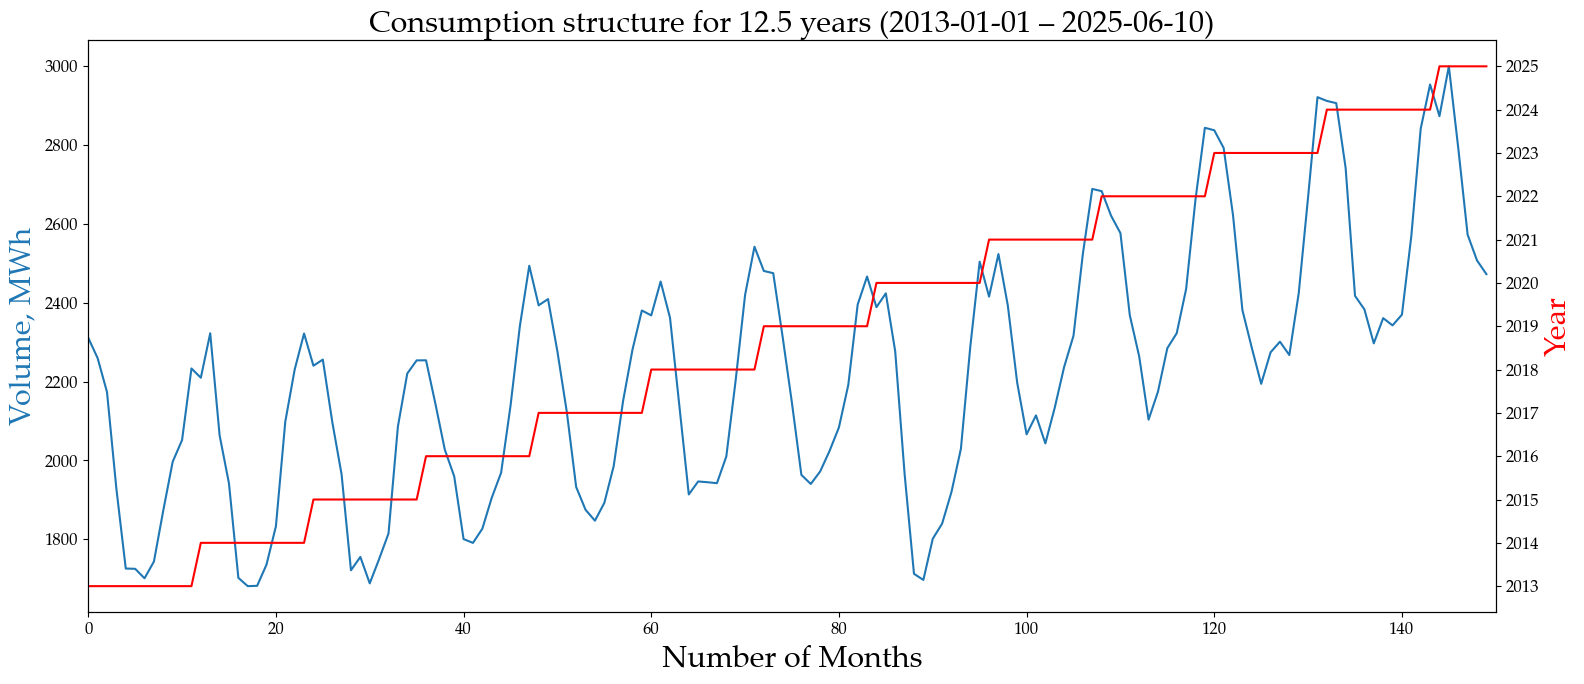

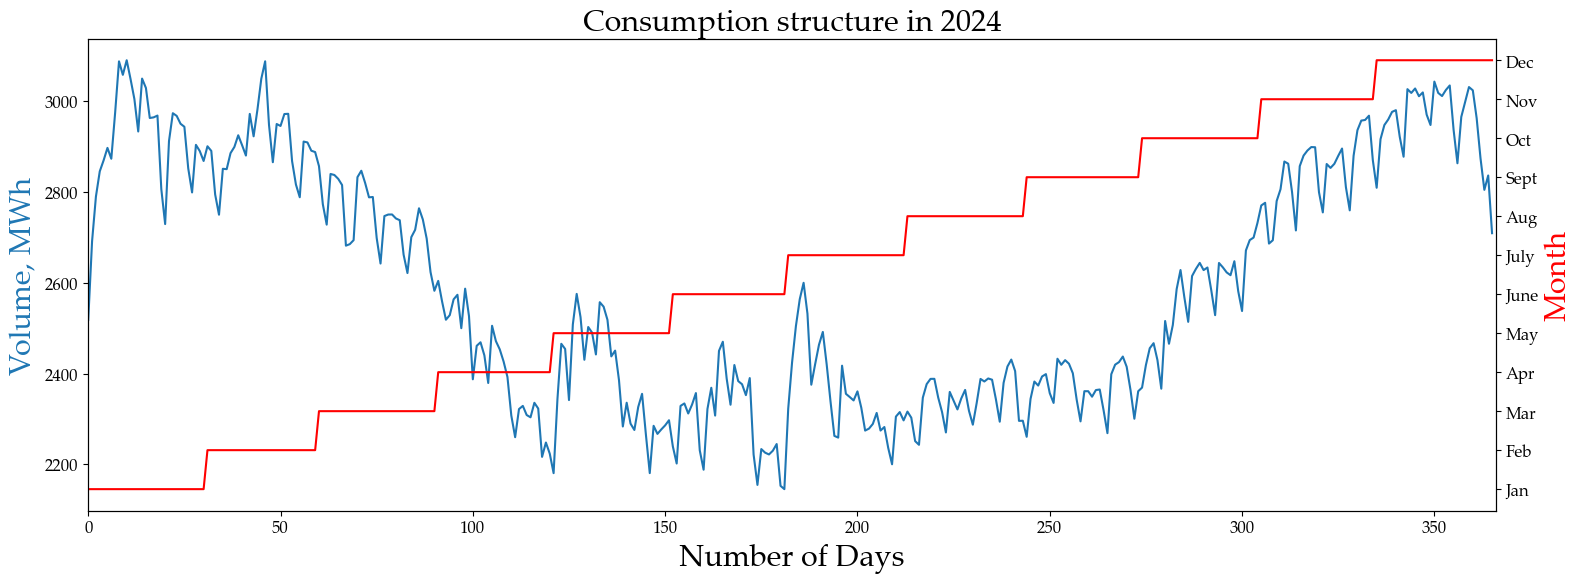

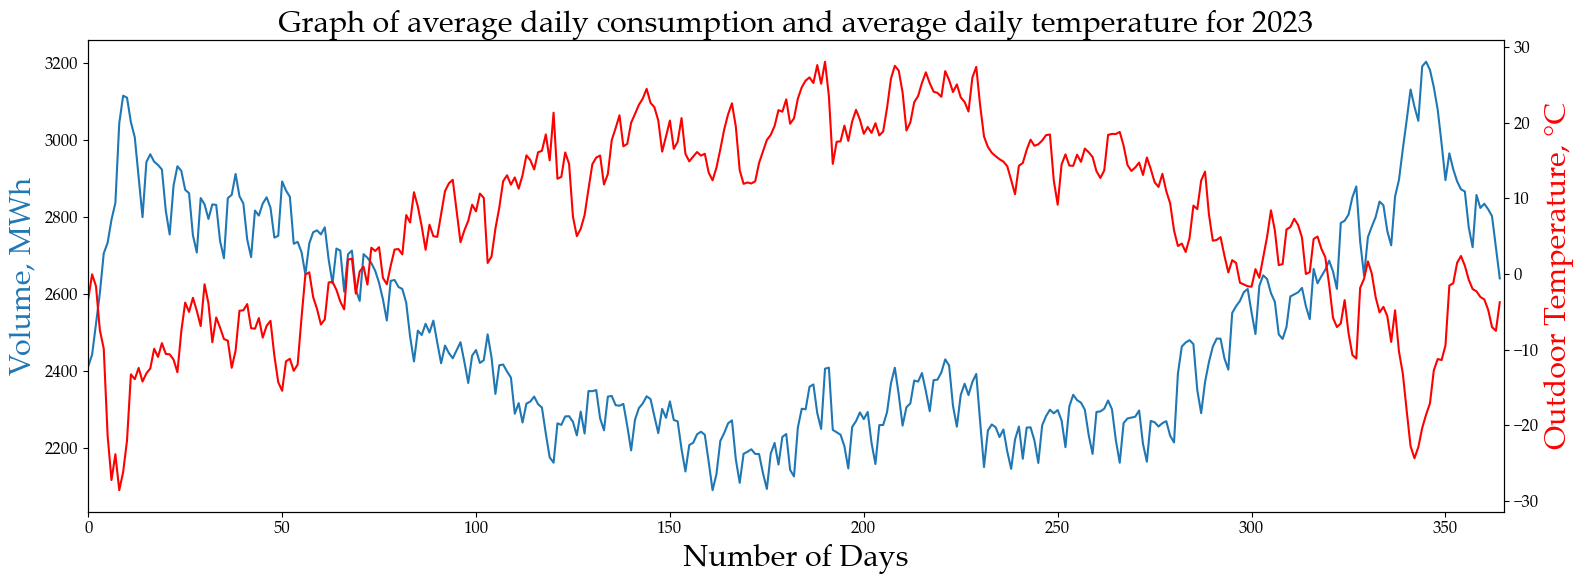

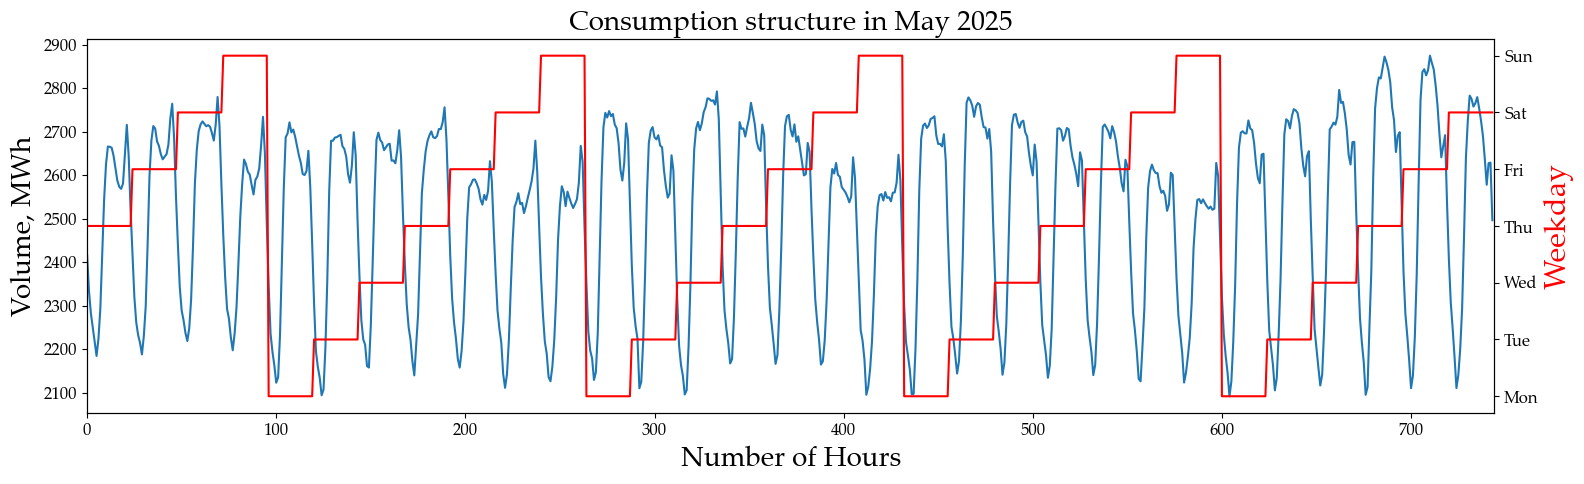

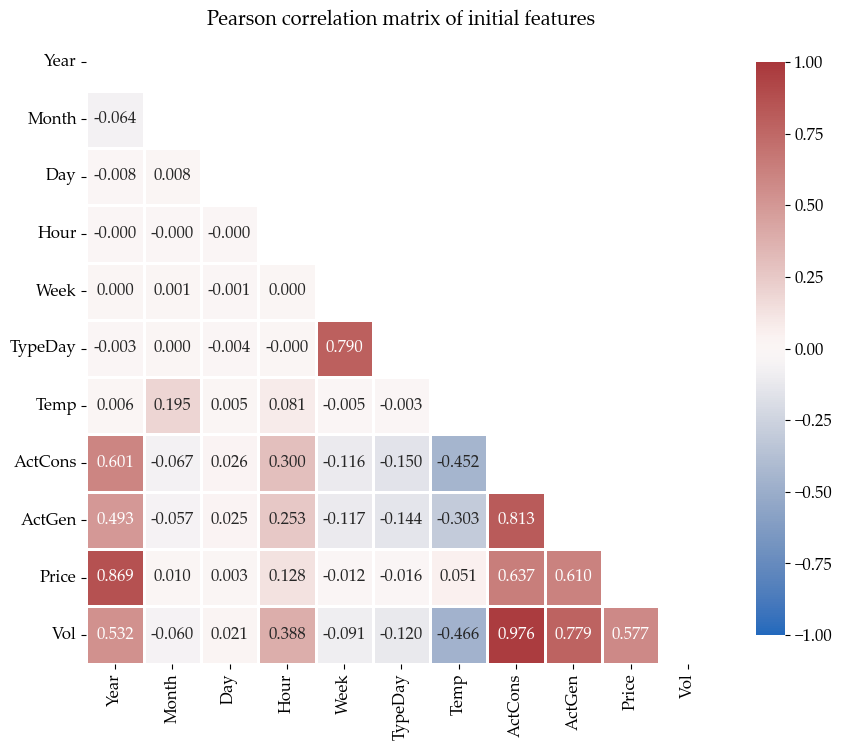

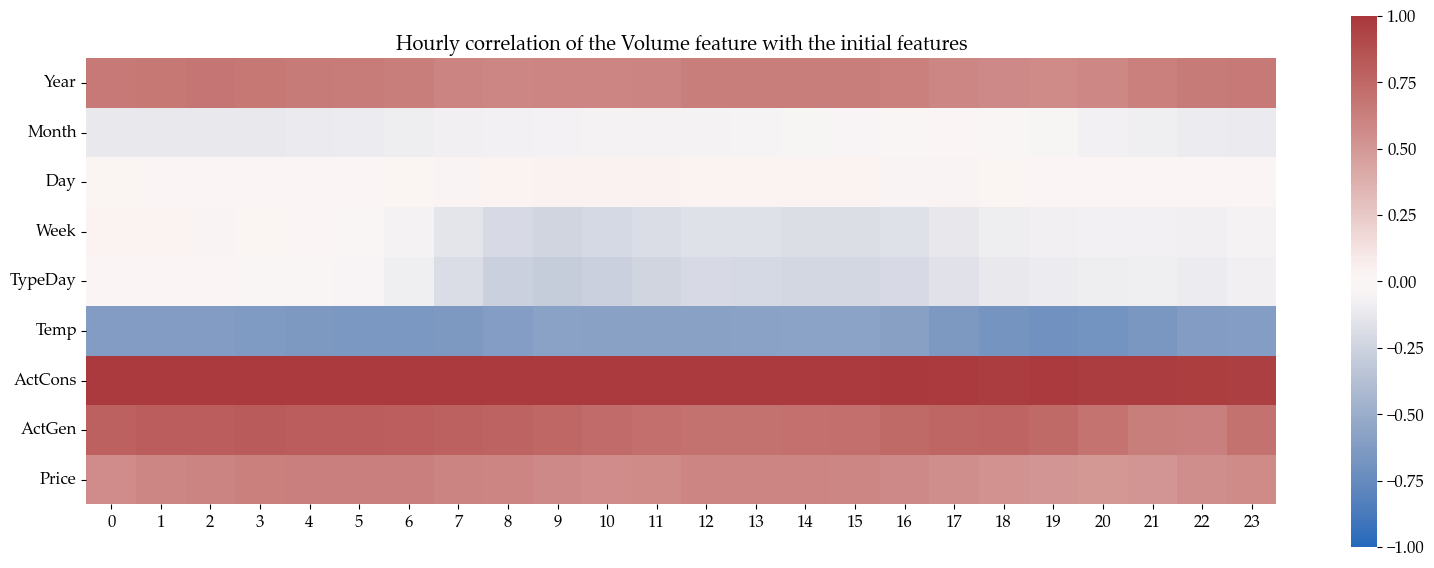

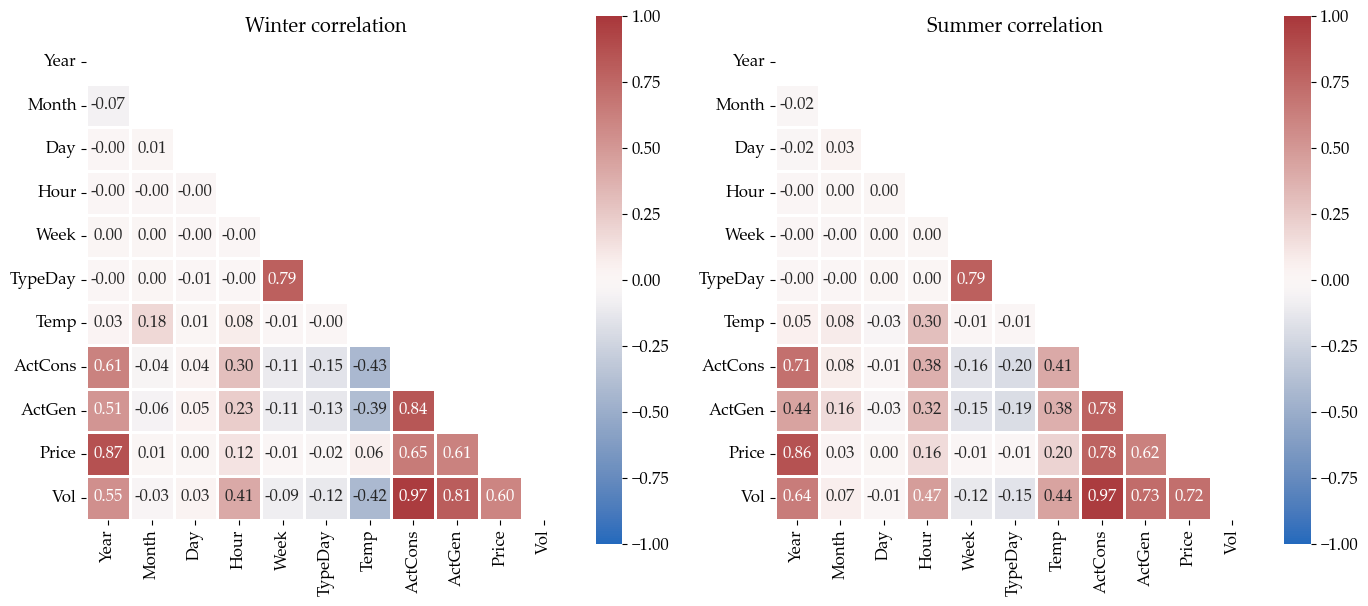

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Подготовленный датасет для N-BEATSx:
                   ds         y  Hour  Month  Weekday  TypeDay  Temperature  \
0 2013-01-08 01:00:00  2017.102     1      1        1        0         -6.1   
1 2013-01-08 02:00:00  1964.942     2      1        1        0         -6.1   
2 2013-01-08 03:00:00  1938.221     3      1        1        0         -6.0   
3 2013-01-08 04:00:00  1929.957     4      1        1        0         -6.0   
4 2013-01-08 05:00:00  1950.473     5      1        1        0         -6.0   

   unique_id  
0          1  
1          1  
2          1  
3          1  
4          1  

Обучающая выборка: 87479 записей
Валидационная выборка: 8760 записей
Тестовая выборка: 3624 записей
Период теста: 2025-01-01 00:00:00 -> 2025-05-31 23:00:00
Начало обучения...


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  4.3 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 4.2 M                                                                                            
Non-trainable params: 9.4 K                                                                                        
Total params: 4.3 M                                                                                                
Total estimated model params size (MB): 17                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Обучение завершено.


Exception: you must define `n_windows` or `test_size` but not both

In [14]:
# =============================================================================
# 12. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ (опционально)
# =============================================================================
# Можно сохранить прогнозы в CSV
cv_df[['ds', 'y', 'NBEATSx']].to_csv('nbeatsx_predictions.csv', index=False)